In [2]:
import pandas as pd

# ---------------------------
# 1. 분석 맥락: 모델 Precision 값 (ipynb 결과 반영)
# ---------------------------
precision_baseline = 0.875   # Logistic Regression
precision_lightgbm = 0.979  # LightGBM

# ---------------------------
# 2. ROI 가정 설정
# ---------------------------
COST_PER_PERSON = 1000   # 1명 타겟팅 비용 (예: 1천 원)
TARGET_SIZES = [1000, 10000]  # 1천명, 1만명 집행 시뮬레이션

# ---------------------------
# 3. 불필요 타겟팅 비용 계산 함수
# ---------------------------
def waste_summary(precision: float, target_size: int, cost_per_person: int):
    """
    Precision을 기반으로, 주어진 타겟 규모에서 발생하는
    불필요 타겟팅 인원(False Positive)과 비용을 계산
    """
    predicted_positive = target_size
    true_positive = precision * predicted_positive
    false_positive = predicted_positive - true_positive
    wasted_cost = false_positive * cost_per_person
    return {
        "target_size": target_size,
        "predicted_positive": predicted_positive,
        "true_positive(실제 구매자)": round(true_positive),
        "false_positive(불필요 타겟)": round(false_positive),
        "wasted_cost(원)": int(wasted_cost)
    }

# ---------------------------
# 4. 모델별 결과 정리
# ---------------------------
rows = []
for N in TARGET_SIZES:
    rows.append({"model":"Baseline(LogReg)", **waste_summary(precision_baseline, N, COST_PER_PERSON)})
    rows.append({"model":"LightGBM", **waste_summary(precision_lightgbm, N, COST_PER_PERSON)})

df_waste = pd.DataFrame(rows)

# ---------------------------
# 5. 절감 효과 비교 테이블
# ---------------------------
def savings_table(dfw: pd.DataFrame):
    out = []
    for N in sorted(dfw["target_size"].unique()):
        b = dfw[(dfw["model"]=="Baseline(LogReg)") & (dfw["target_size"]==N)].iloc[0]
        l = dfw[(dfw["model"]=="LightGBM") & (dfw["target_size"]==N)].iloc[0]
        saved_fp = b["false_positive(불필요 타겟)"] - l["false_positive(불필요 타겟)"]
        saved_cost = b["wasted_cost(원)"] - l["wasted_cost(원)"]
        reduction_ratio = (saved_fp / b["false_positive(불필요 타겟)"]) * 100
        out.append({
            "target_size": N,
            "Baseline_FP": b["false_positive(불필요 타겟)"],
            "LightGBM_FP": l["false_positive(불필요 타겟)"],
            "FP감소(명)": int(saved_fp),
            "FP감소율(%)": round(reduction_ratio, 1),
            "절감액(원)": int(saved_cost)
        })
    return pd.DataFrame(out)

df_saving = savings_table(df_waste)

# ---------------------------
# 6. 출력
# ---------------------------
print("=== 모델별 낭비 비용 비교 ===")
print(df_waste)
print("\n=== 절감 효과 비교 ===")
print(df_saving)

=== 모델별 낭비 비용 비교 ===
              model  target_size  predicted_positive  true_positive(실제 구매자)  \
0  Baseline(LogReg)         1000                1000                    875   
1          LightGBM         1000                1000                    979   
2  Baseline(LogReg)        10000               10000                   8750   
3          LightGBM        10000               10000                   9790   

   false_positive(불필요 타겟)  wasted_cost(원)  
0                     125          125000  
1                      21           21000  
2                    1250         1250000  
3                     210          210000  

=== 절감 효과 비교 ===
   target_size  Baseline_FP  LightGBM_FP  FP감소(명)  FP감소율(%)   절감액(원)
0         1000          125           21      104      83.2   104000
1        10000         1250          210     1040      83.2  1040000


In [4]:
display(df_waste)

,model,target_size,predicted_positive,true_positive(실제 구매자),false_positive(불필요 타겟),wasted_cost(원)
0,Baseline(LogReg),1000,1000,875,125,125000
1,LightGBM,1000,1000,979,21,21000
2,Baseline(LogReg),10000,10000,8750,1250,1250000
3,LightGBM,10000,10000,9790,210,210000


In [6]:
display(df_saving)

,target_size,Baseline_FP,LightGBM_FP,FP감소(명),FP감소율(%),절감액(원)
0,1000,125,21,104,83.2,104000
1,10000,1250,210,1040,83.2,1040000


1. **Baseline(LogReg) Precision = 87.5%**
→ 타겟 1,000명 중 약 125명 / 타겟 10,000명 중 약 1,250명 불필요 타겟팅

2. **LightGBM Precision = 97.9%**
→ 타겟 1,000명 중 약 21명 / 타겟 10,000명 중 약 210명 불필요 타겟팅

따라서 불필요 타겟팅이 약 **83% 감소** → ROI 개선(광고비 절감 효과)

In [11]:
import matplotlib.pyplot as plt

# 운영체제에 따라 폰트 설정
if plt.sys.platform == 'win32': # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif plt.sys.platform == 'darwin': # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else: # Linux 또는 기타 환경
    # 시스템에 설치된 한글 폰트를 지정합니다. (예: NanumGothic)
    # 이 폰트가 없다면 별도로 설치하거나 폰트 위치를 지정해야 합니다.
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

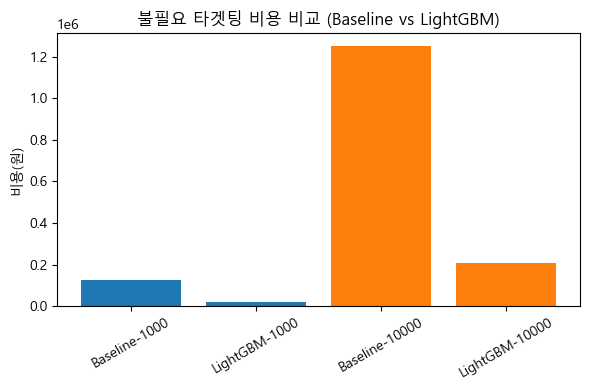

In [13]:
# [07] 시각화: 모델별 불필요 비용 비교
plt.figure(figsize=(6,4))
for N in TARGET_SIZES:
    b_cost = df_waste[(df_waste["model"]=="Baseline(LogReg)") & (df_waste["target_size"]==N)]["wasted_cost(원)"].iloc[0]
    l_cost = df_waste[(df_waste["model"]=="LightGBM") & (df_waste["target_size"]==N)]["wasted_cost(원)"].iloc[0]
    plt.bar([f"Baseline-{N}", f"LightGBM-{N}"], [b_cost, l_cost])

plt.title("불필요 타겟팅 비용 비교 (Baseline vs LightGBM)")
plt.ylabel("비용(원)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### ROI 시뮬레이션 결과 (Baseline vs LightGBM)
| 타겟 인원   | Baseline(LogReg) 낭비 | LightGBM 낭비     | 절감 인원  | 절감율   | 절감액(원)     |
| ------- | ------------------- | --------------- | ------ | ----- | ---------- |
| 1,000명  | 125명 (125,000원)     | 21명 (21,000원)   | 104명   | 83.2% | 104,000원   |
| 10,000명 | 1,250명 (1,250,000원) | 210명 (210,000원) | 1,040명 | 83.2% | 1,040,000원 |